# Weighted Directed Graph for a City Transportation Network

**Representation choice: Adjacency List**

A real transportation network is *sparse* — each city connects to only a
handful of others, not to every city in the network. An adjacency list uses
O(V + E) space and gives O(degree) access to a node's neighbors, whereas an
adjacency matrix always costs O(V²) space regardless of how sparse the graph
actually is, and requires scanning a full row (O(V)) just to find a node's
neighbors.

This matters directly for our algorithms:
- Dijkstra's and Prim's repeatedly need "all neighbors of the current node" — adjacency list gives this directly.
- Bellman-Ford iterates over *all edges* each pass — an adjacency list also gives us an edge list cheaply.

Edges are directed and weighted (e.g. representing one-way roads, or travel
time/distance/cost between two cities).

In [1]:
class Graph:
    """
    Weighted directed graph using an adjacency list.
    Nodes are city names (strings). Edges: node -> list of (neighbor, weight).
    """

    def __init__(self):
        self.adj = {}  # node -> list of (neighbor, weight)

    def add_node(self, node):
        if node not in self.adj:
            self.adj[node] = []

    def add_edge(self, u, v, weight):
        """Adds a directed edge u -> v with the given weight."""
        self.add_node(u)
        self.add_node(v)
        self.adj[u].append((v, weight))

    def nodes(self):
        return list(self.adj.keys())

    def edges(self):
        """Returns all edges as (u, v, weight) tuples."""
        result = []
        for u in self.adj:
            for v, w in self.adj[u]:
                result.append((u, v, w))
        return result

    def neighbors(self, u):
        return self.adj.get(u, [])

    def num_nodes(self):
        return len(self.adj)

    def num_edges(self):
        return sum(len(v) for v in self.adj.values())

    def __repr__(self):
        lines = []
        for u in self.adj:
            for v, w in self.adj[u]:
                lines.append(f"  {u} -> {v}  (weight={w})")
        return f"Graph({self.num_nodes()} nodes, {self.num_edges()} edges)\n" + "\n".join(lines)

## Sanity Test — Small Sample City Network

In [2]:
g = Graph()

# A small directed, weighted road network between Nepali cities
# (weight = travel time in minutes, purely illustrative)
edges = [
    ("Kathmandu", "Bhaktapur", 25),
    ("Kathmandu", "Lalitpur", 15),
    ("Lalitpur", "Bhaktapur", 20),
    ("Bhaktapur", "Dhulikhel", 30),
    ("Lalitpur", "Dhulikhel", 45),
    ("Dhulikhel", "Nagarkot", 35),
    ("Kathmandu", "Nagarkot", 60),
    ("Nagarkot", "Bhaktapur", 28),
]

for u, v, w in edges:
    g.add_edge(u, v, w)

print(g)
print("\nNodes:", g.nodes())
print("Num nodes:", g.num_nodes())
print("Num edges:", g.num_edges())
print("\nNeighbors of Kathmandu:", g.neighbors("Kathmandu"))

Graph(5 nodes, 8 edges)
  Kathmandu -> Bhaktapur  (weight=25)
  Kathmandu -> Lalitpur  (weight=15)
  Kathmandu -> Nagarkot  (weight=60)
  Bhaktapur -> Dhulikhel  (weight=30)
  Lalitpur -> Bhaktapur  (weight=20)
  Lalitpur -> Dhulikhel  (weight=45)
  Dhulikhel -> Nagarkot  (weight=35)
  Nagarkot -> Bhaktapur  (weight=28)

Nodes: ['Kathmandu', 'Bhaktapur', 'Lalitpur', 'Dhulikhel', 'Nagarkot']
Num nodes: 5
Num edges: 8

Neighbors of Kathmandu: [('Bhaktapur', 25), ('Lalitpur', 15), ('Nagarkot', 60)]


## Visualizing the Graph

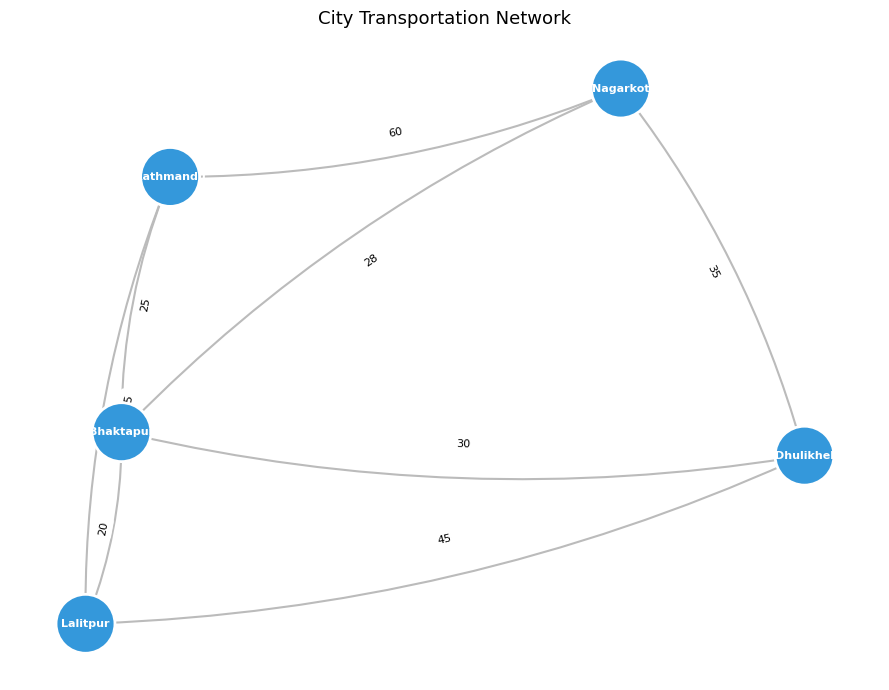

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_graph(graph, title="City Transportation Network", highlight_edges=None, highlight_nodes=None, node_labels=None):
    """
    Draws our custom Graph object using networkx for layout only.
    highlight_edges: set of (u, v) tuples to draw in a different color (e.g. shortest path / MST edges)
    highlight_nodes: set of node names to highlight (e.g. visited nodes)
    node_labels: optional dict of node -> extra label text (e.g. distance)
    """
    G = nx.DiGraph()
    for u, v, w in graph.edges():
        G.add_edge(u, v, weight=w)

    pos = nx.spring_layout(G, seed=42, k=1.2)

    plt.figure(figsize=(9, 7))

    highlight_edges = highlight_edges or set()
    highlight_nodes = highlight_nodes or set()

    edge_colors = ['#e74c3c' if (u, v) in highlight_edges else '#bbbbbb' for u, v in G.edges()]
    edge_widths = [3 if (u, v) in highlight_edges else 1.5 for u, v in G.edges()]
    node_colors = ['#e74c3c' if n in highlight_nodes else '#3498db' for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1800, edgecolors='white', linewidths=2)
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths,
                            arrowsize=20, connectionstyle='arc3,rad=0.1')

    labels = {}
    for n in G.nodes():
        text = n
        if node_labels and n in node_labels:
            text += f"\n({node_labels[n]})"
        labels[n] = text
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_weight='bold', font_color='white')

    edge_labels = {(u, v): d['weight'] for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title(title, fontsize=13)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

draw_graph(g)